In [39]:
# ==============================
# Importing the libraries
# ==============================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [40]:
# ==============================
# Reading the dataset
# ==============================
df = pd.read_csv('/content/synthetic_ai_model_metrics_2018_2025.csv')
df.head()

,record_id,year,quarter,model_type,task_type,model_size_million_params,training_framework,epochs,batch_size,learning_rate,...,model_accuracy,f1_score,roc_auc,gpu_type,gpu_memory_gb,power_consumption_kwh,carbon_emission_kg,cloud_provider,training_cost_usd,inference_cost_per_1k_requests
0,1,2020,Q1,Diffusion,detection,73.55,PyTorch,47,128,0.000363,...,0.809,0.793,0.838,RTX3090,24,6.77,3.99,AWS,46.42,0.1923
1,2,2024,Q3,LLM,generation,55.33,JAX,46,128,0.000012,...,0.786,0.736,0.810,V100,32,11.43,6.54,AWS,31.00,0.3792
2,3,2021,Q4,Diffusion,generation,57.81,TensorFlow,13,64,0.000011,...,0.873,0.856,0.895,T4,16,3.92,2.36,GCP,15.64,0.9187
3,4,2022,Q2,Transformer,generation,41.39,TensorFlow,22,16,0.000355,...,0.825,0.807,0.837,T4,16,6.12,2.79,Azure,18.38,5.6599
4,5,2021,Q4,LLM,classification,24.34,TensorFlow,49,128,0.000019,...,0.750,0.739,0.784,T4,16,4.10,2.43,GCP,16.12,1.5939


In [41]:
df.shape

(25000, 26)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       25000 non-null  int64  
 1   year                            25000 non-null  int64  
 2   quarter                         25000 non-null  object 
 3   model_type                      25000 non-null  object 
 4   task_type                       25000 non-null  object 
 5   model_size_million_params       25000 non-null  float64
 6   training_framework              25000 non-null  object 
 7   epochs                          25000 non-null  int64  
 8   batch_size                      25000 non-null  int64  
 9   learning_rate                   25000 non-null  float64
 10  training_time_hours             25000 non-null  float64
 11  final_train_loss                25000 non-null  float64
 12  final_val_loss                  

In [43]:
df.describe()

,record_id,year,model_size_million_params,epochs,batch_size,learning_rate,training_time_hours,final_train_loss,final_val_loss,overfitting_score,inference_latency_ms,throughput_samples_per_sec,model_accuracy,f1_score,roc_auc,gpu_memory_gb,power_consumption_kwh,carbon_emission_kg,training_cost_usd,inference_cost_per_1k_requests
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,2021.471120,65.011107,27.059440,59.82016,0.000216,6.487893,0.628000,0.832290,0.204290,336.191375,9.245280,0.818907,0.788946,0.843931,27.906880,7.463217,3.718221,26.056546,1.850689
std,7217.022701,2.287272,43.354847,13.016139,42.83030,0.000250,4.875510,0.332932,0.351318,0.112816,312.597297,20.697393,0.078605,0.079443,0.079086,8.968263,5.834845,3.076063,21.682679,2.101557
min,1.000000,2018.000000,5.770000,5.000000,16.00000,0.000010,0.330000,0.050000,0.066700,0.010000,1.970000,0.030000,0.502000,0.487000,0.523000,16.000000,0.410000,0.200000,0.950000,0.004600
25%,6250.750000,2019.000000,36.030000,16.000000,16.00000,0.000032,3.270000,0.338375,0.542275,0.106000,120.572500,1.650000,0.766000,0.736000,0.791000,16.000000,3.640000,1.720000,12.070000,0.499275
50%,12500.500000,2021.000000,53.915000,27.000000,32.00000,0.000101,5.180000,0.630000,0.833800,0.204150,250.570000,3.640000,0.819000,0.790000,0.844000,24.000000,5.870000,2.850000,19.940000,1.180250
75%,18750.250000,2023.000000,81.355000,38.000000,64.00000,0.000319,8.150000,0.917325,1.121025,0.301600,454.275000,8.390000,0.872000,0.843000,0.898000,32.000000,9.390000,4.672500,32.810000,2.438000
max,25000.000000,2025.000000,557.340000,49.000000,128.00000,0.001000,60.100000,1.200000,1.596100,0.400000,3891.490000,512.020000,0.990000,0.980000,1.030000,40.000000,77.920000,50.890000,344.460000,35.061800


In [44]:
# ==============================
# Handling missing values
# ==============================
df.isnull().sum()

,0
record_id,0
year,0
quarter,0
model_type,0
task_type,0
model_size_million_params,0
training_framework,0
epochs,0
batch_size,0
learning_rate,0


In [45]:
# ==============================
# Searching for duplicates
# ==============================
df = df.dropna()

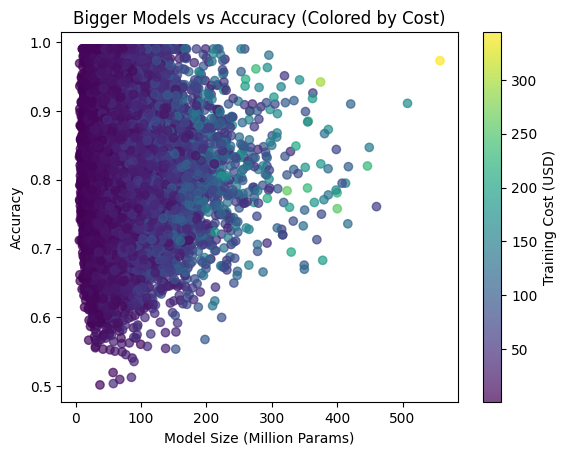

In [46]:
# ==============================
# Finding useful information using visualizations
# ==============================
import matplotlib.pyplot as plt

plt.figure()

scatter = plt.scatter(
    df['model_size_million_params'],
    df['model_accuracy'],
    c=df['training_cost_usd'],   # color by cost
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='Training Cost (USD)')
plt.xlabel('Model Size (Million Params)')
plt.ylabel('Accuracy')
plt.title('Bigger Models vs Accuracy (Colored by Cost)')
plt.show()

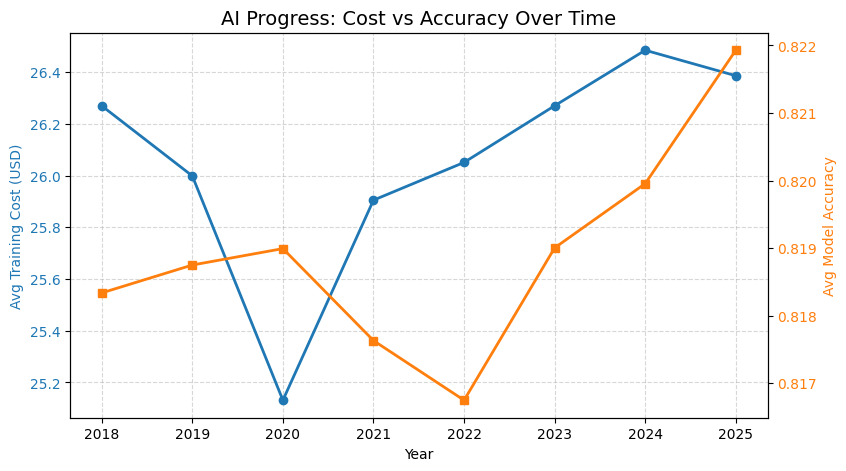

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate data
df_year = df.groupby('year').agg({
    'training_cost_usd': 'mean',
    'model_accuracy': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(9,5))

# Line 1: Training Cost
color1 = 'tab:blue'
ax1.plot(
    df_year['year'],
    df_year['training_cost_usd'],
    marker='o',
    color=color1,
    linewidth=2
)
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Training Cost (USD)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Line 2: Accuracy
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.plot(
    df_year['year'],
    df_year['model_accuracy'],
    marker='s',
    color=color2,
    linewidth=2
)
ax2.set_ylabel('Avg Model Accuracy', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Title + grid
plt.title('AI Progress: Cost vs Accuracy Over Time', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)

plt.show()

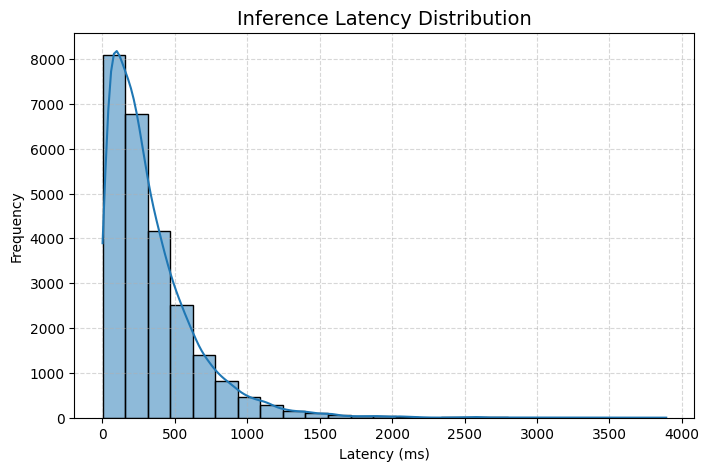

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df['inference_latency_ms'],
    bins=25,
    kde=True
)

plt.title('Inference Latency Distribution', fontsize=14)
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

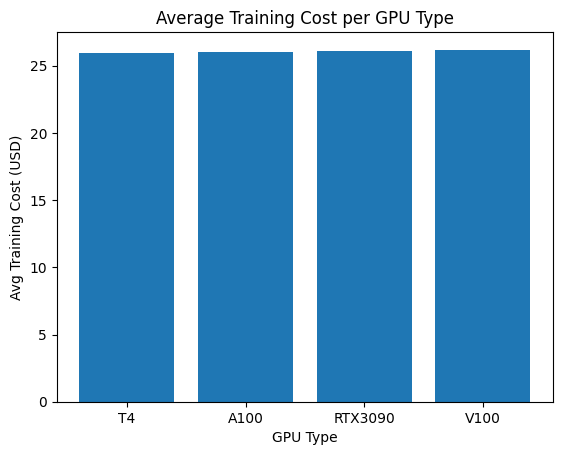

In [49]:
# Aggregate metrics by GPU
gpu_stats = df.groupby('gpu_type').agg({
    'training_cost_usd': 'mean',
    'power_consumption_kwh': 'mean',
    'model_accuracy': 'mean'
}).reset_index()

gpu_stats = gpu_stats.sort_values('training_cost_usd')

# Plot: Cost vs GPU
plt.figure()
plt.bar(gpu_stats['gpu_type'], gpu_stats['training_cost_usd'])
plt.xlabel('GPU Type')
plt.ylabel('Avg Training Cost (USD)')
plt.title('Average Training Cost per GPU Type')
plt.show()

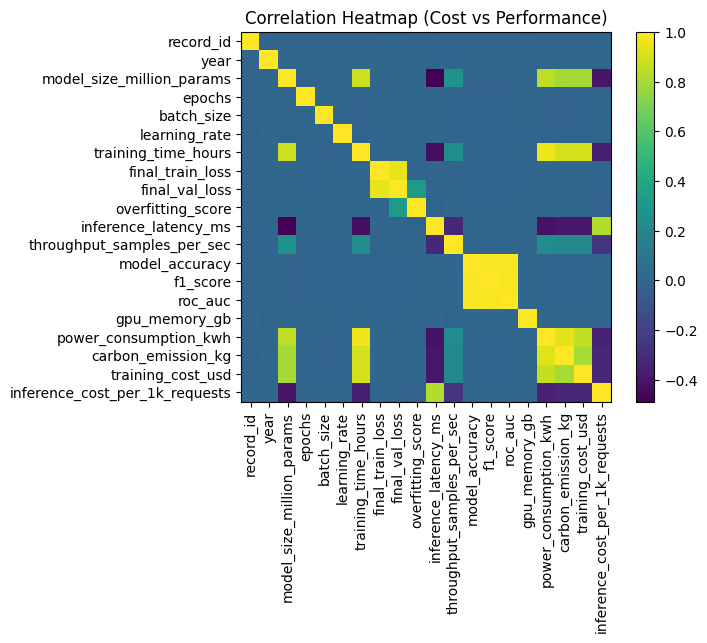

In [50]:
# Heatmap (Correlation matrix)
plt.figure()
corr = df.corr(numeric_only=True)
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Correlation Heatmap (Cost vs Performance)')
plt.show()

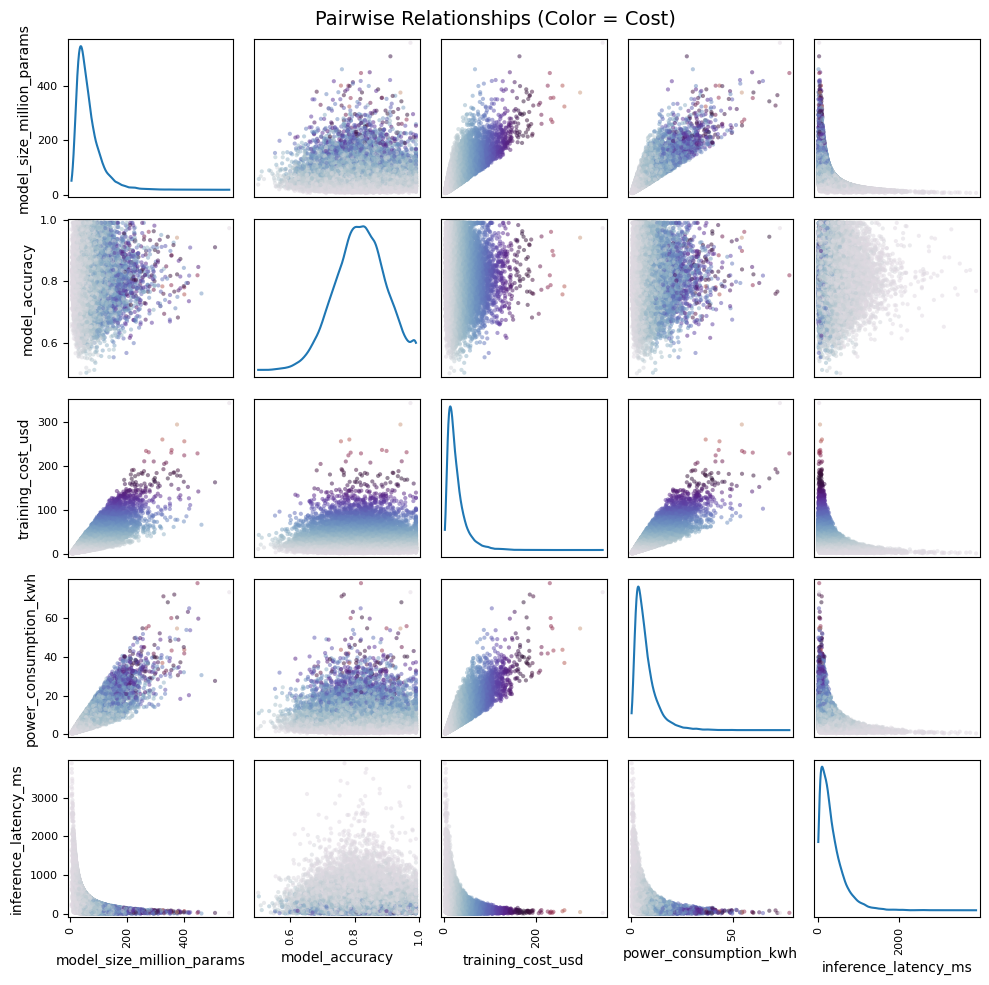

In [51]:
cols = [
    'model_size_million_params',
    'model_accuracy',
    'training_cost_usd',
    'power_consumption_kwh',
    'inference_latency_ms'
]

# 1. Pairwise scatter matrix
axes = pd.plotting.scatter_matrix(
    df[cols],
    figsize=(10,10),
    diagonal='kde',
    alpha=0.5,
    c=df['training_cost_usd'],
    cmap='twilight'
)

plt.suptitle("Pairwise Relationships (Color = Cost)", fontsize=14)
plt.tight_layout()
plt.show()


In [52]:
# ==============================
# Train-test split
# ==============================
features = [
    'model_size_million_params','epochs','batch_size','learning_rate',
    'training_time_hours','gpu_memory_gb','power_consumption_kwh','training_cost_usd'
]

X = df[features]
y = df['model_accuracy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
!pip install optuna

In [54]:
# ==============================
# Hyperparameter tuning
# ==============================
from xgboost import XGBRegressor
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42
    }

    model = XGBRegressor(**params)

    pipe = Pipeline([
        ("model", model)
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=3,
        scoring="neg_root_mean_squared_error"
    )

    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\nBest Hyperparameters:")
print(study.best_params)

[I 2026-05-02 14:58:54,912] A new study created in memory with name: no-name-6198e1e8-3ed6-4405-9f4c-a0277f7652e8
[I 2026-05-02 14:58:55,824] Trial 0 finished with value: -0.07866656634122256 and parameters: {'n_estimators': 454, 'max_depth': 8, 'learning_rate': 0.06062232400597869, 'subsample': 0.6051740986964981, 'colsample_bytree': 0.9816229921556284, 'gamma': 3.5736924783492503, 'reg_alpha': 2.260764802997973, 'reg_lambda': 3.228762443676611}. Best is trial 0 with value: -0.07866656634122256.
[I 2026-05-02 14:58:56,105] Trial 1 finished with value: -0.07866712894133725 and parameters: {'n_estimators': 146, 'max_depth': 10, 'learning_rate': 0.11976765371068218, 'subsample': 0.9699410309073513, 'colsample_bytree': 0.6515196201277975, 'gamma': 3.958831491519841, 'reg_alpha': 0.6029287872331618, 'reg_lambda': 4.139049838847265}. Best is trial 0 with value: -0.07866656634122256.
[I 2026-05-02 14:58:56,336] Trial 2 finished with value: -0.07866702749554401 and parameters: {'n_estimators'


Best Hyperparameters:
{'n_estimators': 495, 'max_depth': 7, 'learning_rate': 0.08084534883620598, 'subsample': 0.6838537349916869, 'colsample_bytree': 0.7557874315197166, 'gamma': 0.018116993430886463, 'reg_alpha': 2.892920397202468, 'reg_lambda': 1.4298564632290016}


In [55]:
# ==============================
# FINAL MODEL WITH BEST PARAMS
# ==============================
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

best_model = XGBRegressor(**study.best_params)

pipeline = Pipeline([
    ("model", best_model)
])

pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nTuned Model Performance:")
print("RMSE:", rmse)
print("R2:", r2)


Tuned Model Performance:
RMSE: 0.07844089467047957
R2: -0.0028132135034615313


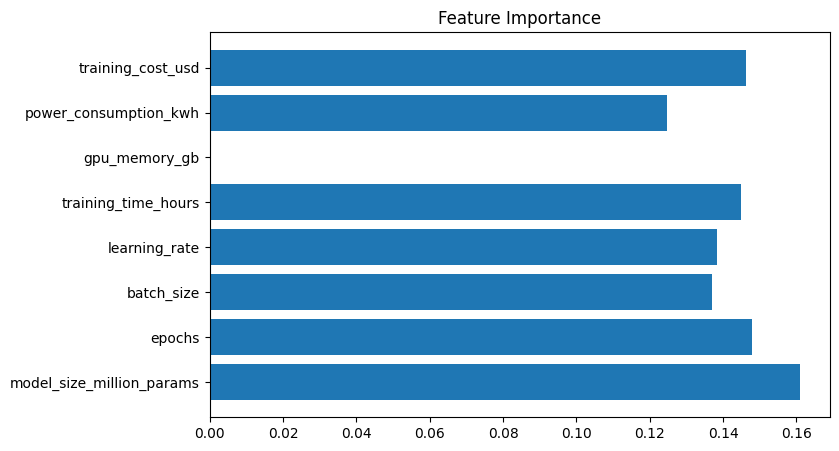

In [56]:
# ==============================
# FEATURE IMPORTANCE
# ==============================

# All features used for training the model
all_features = features

importances = pipeline.named_steps["model"].feature_importances_

plt.figure(figsize=(8,5))
plt.barh(all_features, importances)
plt.title("Feature Importance")
plt.show()

In [57]:
# ==============================
# TEST BEST CONFIG
# ==============================

# Let's create a sample input using the mean of the training features for demonstration.
sample_input = pd.DataFrame([X_train.mean()], columns=features)

best_perf = pipeline.predict(sample_input)[0]

print("\nPredicted Performance for Best Setup (on sample input):", best_perf)


Predicted Performance for Best Setup (on sample input): 0.81976867
